In [4]:
import numpy as np
import pandas as pd


In [ ]:
import pandas as pd

df = pd.read_csv("The_Cancer_data_1500_V2.csv")
df.head()



,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1500 non-null   int64  
 1   Gender            1500 non-null   int64  
 2   BMI               1500 non-null   float64
 3   Smoking           1500 non-null   int64  
 4   GeneticRisk       1500 non-null   int64  
 5   PhysicalActivity  1500 non-null   float64
 6   AlcoholIntake     1500 non-null   float64
 7   CancerHistory     1500 non-null   int64  
 8   Diagnosis         1500 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 105.6 KB


In [7]:
df.isnull().sum()


Age                 0
Gender              0
BMI                 0
Smoking             0
GeneticRisk         0
PhysicalActivity    0
AlcoholIntake       0
CancerHistory       0
Diagnosis           0
dtype: int64

In [8]:
df=df.dropna()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
print(df.columns)

Index(['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity',
       'AlcoholIntake', 'CancerHistory', 'Diagnosis'],
      dtype='object')


In [12]:
df.columns = df.columns.str.strip()

<Axes: >

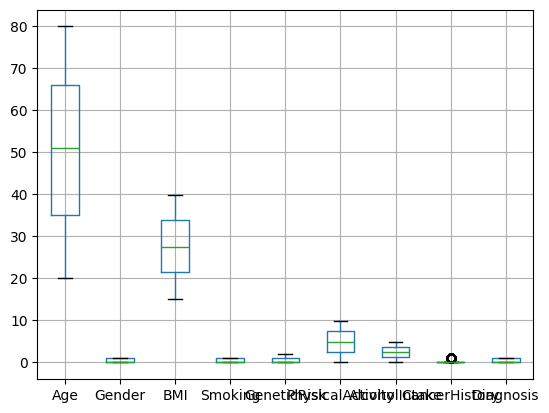

In [13]:
df.boxplot()

In [14]:
import matplotlib.pyplot as plt

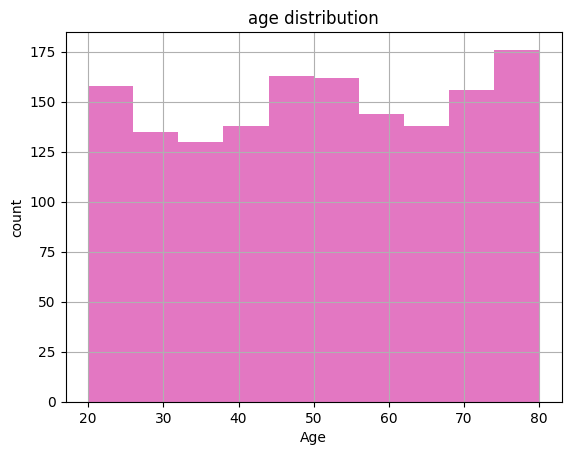

In [23]:
df['Age'].hist(bins=10)
plt.title("age distribution")
plt.xlabel("Age")
plt.ylabel("count")
plt.show()

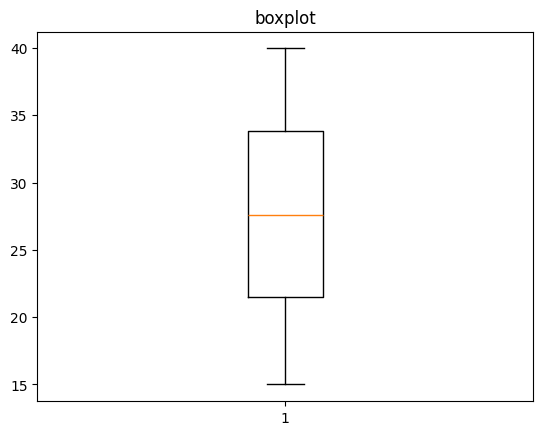

In [31]:
plt.boxplot(df["BMI"])
plt.title("boxplot")
plt.show()

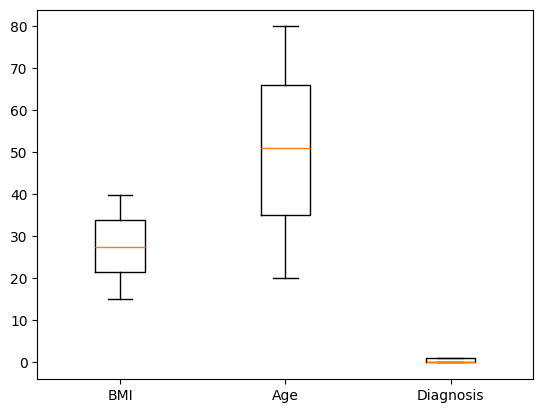

In [33]:
plt.boxplot([df["BMI"], df["Age"], df["Diagnosis"]])
plt.xticks([1,2,3], ["BMI","Age","Diagnosis"])
plt.show()

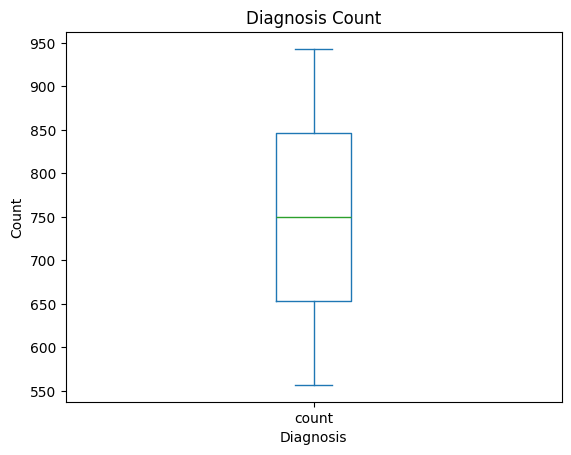

In [40]:
df['Diagnosis'].value_counts().plot(kind='box')
plt.title("Diagnosis Count")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

In [37]:
print(df['Diagnosis'].value_counts())

Diagnosis
0    943
1    557
Name: count, dtype: int64


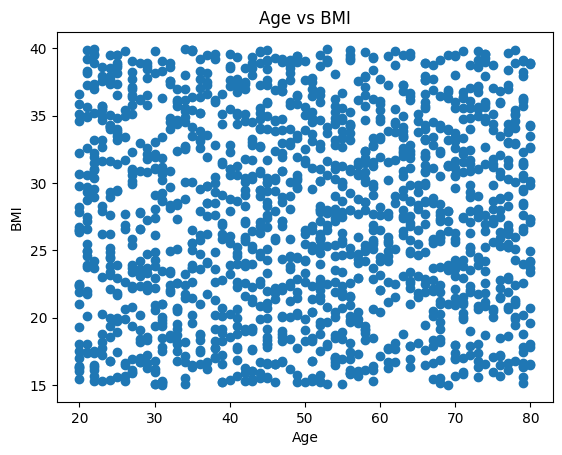

In [41]:
plt.scatter(df['Age'], df['BMI'])
plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Age vs BMI")
plt.show()

In [43]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

ModuleNotFoundError: No module named 'sklearn'

In [44]:
import sys
print(sys.executable)

c:\Program Files\Python312\python.exe


In [45]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 509.0 kB/s eta 0:00:16
   -- ------------------------------------- 0.5/8.2 MB 509.0 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/8.2 MB 589.1 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/8.2 MB 589.1 kB/s eta 0:00:13
   ----- ---------------------------------- 1.0/8.2 MB 578.7 kB/s eta 0:00:13
   ----- ---------------------------------- 1.0/8.2 MB 578.7 kB/s eta 0:00:13
   ------ --------------------------------- 1.3/8.2 MB 604.7 kB/s eta 0:00:12
   ------ --------------------------------- 1.3/8.2 MB 604.7 kB/s eta 0:00:12
   ------- -----------


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)



In [48]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X)

print("Accuracy:", accuracy_score(y, y_pred))

Accuracy: 1.0


In [49]:
from sklearn.metrics import classification_report

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       943
           1       1.00      1.00      1.00       557

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



In [50]:
from sklearn.model_selection import train_test_split

X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)